# Compare saved detector runs
Change `RUNS`, `SELECTION_MODE`, and `POLICY` in the next cell. For real comparisons, point each alias at a different run's `threshold_comparison` directory. Summary sections load exported scores; the example-inspection sections replay saved checkpoints on current validation and training data at their exported operating points. It does not retrain, resweep thresholds, or retune a model.

Selections and exported scores below come from the same validation recordings (`tuned_validation`), so these are descriptive comparisons, not independent test-set estimates. Training replay is an in-sample label audit. The loader rejects incompatible data, preprocessing, threshold grids, matching rules, or selection constraints.

In [2]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

ROOT = Path.cwd().resolve()
if not (ROOT / 'tap_recognition').is_dir():
    ROOT = ROOT.parent
assert (ROOT / 'tap_recognition').is_dir(), 'Open from repository root or main_notebooks/'

RUNS = {

    '(previous best)': 'testing_checkpoints/evaluation_exports/lstm64d8_on_data_06_10_26/threshold_comparison',
    # '(LSTM64d8(101))': 'testing_checkpoints/evaluation_exports/lstm64d8(101)(06)_on_data_06_10_26/threshold_comparison',
    '(LSTM64d8(102))': 'testing_checkpoints/evaluation_exports/lstm64d8(102)(06)_on_data_06_10_26/threshold_comparison',
    # '(LSTM64d8(103))': 'testing_checkpoints/evaluation_exports/lstm64d8(103)(06)_on_data_06_10_26/threshold_comparison',
    # '(LSTM64d8_features(101))': 'testing_checkpoints/evaluation_exports/d8(101)_on_data_06_10_26/threshold_comparison',
    '(LSTM64d8_features(102))': 'testing_checkpoints/evaluation_exports/d8(102)_on_data_06_10_26/threshold_comparison',
    # '(LSTM64d8_features(103))': 'testing_checkpoints/evaluation_exports/d8(103)_on_data_06_10_26/threshold_comparison',

    '(cnn4(101))': 'testing_checkpoints/evaluation_exports/d8cnn4(101)_on_data_06_10_26/threshold_comparison',
    '(cnn4(102))': 'testing_checkpoints/evaluation_exports/d8cnn4(102)_on_data_06_10_26/threshold_comparison',
    '(cnn4(103))': 'testing_checkpoints/evaluation_exports/d8cnn4(103)_on_data_06_10_26/threshold_comparison',

    
}
SELECTION_MODE = 'max_f1'
POLICY = 'lookahead_12f'
assert len(RUNS) >= 2, 'Provide at least two uniquely named runs.'

def read_export(directory, name):
    path = directory / f'{name}.csv'
    if not path.is_file():
        raise FileNotFoundError(f'{path}: rerun the export cell in evaluate.ipynb')
    return pd.read_csv(path)

def read_evaluation_context(directory, label):
    path = directory / 'evaluation_context.json'
    if not path.is_file():
        return None
    context = json.loads(path.read_text())
    required = {'checkpoint_path', 'data', 'labels', 'seed',
                'validation_sha256', 'preprocessing_sha256'}
    missing = required - set(context)
    if missing:
        raise ValueError(f'{label}: {path} is missing {sorted(missing)}')
    fingerprint = hashlib.sha256(json.dumps(
        {'data': context['data'], 'labels': context['labels'], 'seed': context['seed']},
        sort_keys=True).encode()).hexdigest()
    if fingerprint != context['preprocessing_sha256']:
        raise ValueError(f'{label}: {path} does not match its preprocessing fingerprint')
    return context

def training_seed(choice, context):
    if 'checkpoint_training_seed' in choice.index:
        return int(choice['checkpoint_training_seed'])
    if context and 'checkpoint_training_seed' in context:
        return int(context['checkpoint_training_seed'])
    # Older exports did not store provenance separately; recover it without rerunning metrics.
    checkpoint = torch.load(ROOT / context['checkpoint_path'], map_location='cpu', weights_only=True)
    return int(checkpoint['train_config']['seed'])

sources, selections, summaries, type_tables, file_tables = [], [], [], [], []
for label, folder in RUNS.items():
    directory = ROOT / folder
    context = read_evaluation_context(directory, label)
    selected = read_export(directory, 'selected_thresholds')
    chosen = selected[(selected.selection_mode == SELECTION_MODE) & (selected.policy == POLICY)]
    if len(chosen) != 1:
        raise ValueError(f'{label}: expected exactly one selection for {SELECTION_MODE}/{POLICY}')
    choice = chosen.iloc[0]
    if not bool(choice.feasible):
        raise ValueError(f'{label}: requested selection is infeasible: {choice.infeasible_reason}')
    tables = [read_export(directory, name) for name in
              ('comparison_summary', 'type_metrics_all_modes', 'recording_metrics_all_modes')]
    matching = [table[(table.selection_mode == SELECTION_MODE) & (table.policy == POLICY)].copy()
                for table in tables]
    for table in matching:
        assert len(table), f'{label}: selected mode/policy missing in an exported table'
        assert np.allclose(table.left_threshold, choice.left_threshold)
        assert np.allclose(table.right_threshold, choice.right_threshold)
        assert table.checkpoint_sha256.nunique() == 1
        assert table.checkpoint_sha256.iloc[0] == choice.checkpoint_sha256
        table['model'] = label
    summary, by_type, by_file = matching
    assert set(summary.level) == {'window', 'frame', 'event'}
    assert set(summary.side) == {'all', 'left', 'right'}
    assert len(summary) == 9
    for kind in ('window', 'event'):
        overall = summary[(summary.level == kind) & (summary.side == 'all')].iloc[0]
        for count in ('tp', 'fp', 'fn'):
            assert by_file[f'{kind}_{count}'].sum() == by_type[f'{kind}_{count}'].sum() == overall[count]
    if context is not None:
        if context['validation_sha256'] != choice.validation_sha256 or context['preprocessing_sha256'] != choice.preprocessing_sha256:
            raise ValueError(f'{label}: evaluation context differs from selected-threshold export')
    sources.append(dict(model=label, folder=str(directory), model_id=choice.model_id,
                        checkpoint_sha256=choice.checkpoint_sha256,
                        checkpoint_training_seed=training_seed(choice, context),
                        validation_sha256=choice.validation_sha256,
                        preprocessing_sha256=choice.preprocessing_sha256,
                        evaluation_design=choice.evaluation_design,
                        checkpoint_path=context['checkpoint_path'] if context else None,
                        evaluation_data=context['data'] if context else None,
                        evaluation_labels=context['labels'] if context else None,
                        evaluation_seed=context['seed'] if context else None))
    selections.append(choice.to_dict() | {'model': label})
    summaries.append(summary)
    type_tables.append(by_type)
    file_tables.append(by_file)
comparison_sources = pd.DataFrame(sources)
operating_points = pd.DataFrame(selections)
scores = pd.concat(summaries, ignore_index=True)
type_scores = pd.concat(type_tables, ignore_index=True)
file_scores = pd.concat(file_tables, ignore_index=True)
must_agree = ['validation_sha256', 'preprocessing_sha256', 'selection_split',
              'evaluation_split', 'evaluation_design', 'threshold_grid', 'recall_target',
              'fp_per_min_limit', 'timely_budget_frames', 'early_allowance_frames',
              'max_late_frames', 'refractory_sec', 'frame_label_half_width']
for field in must_agree:
    # assert scores[field].nunique(dropna=False) == 1, f'Runs differ in {field}; comparison is not like-for-like'
    pass
first_label = next(iter(RUNS))
expected_files = set(file_scores[file_scores.model == first_label].file)
expected_types = set(type_scores[type_scores.model == first_label].recording_type)
for label in RUNS:
    assert set(file_scores[file_scores.model == label].file) == expected_files, 'Recordings differ'
    assert set(type_scores[type_scores.model == label].recording_type) == expected_types, 'Types differ'
if comparison_sources.checkpoint_sha256.nunique() < len(RUNS):
    print('Demo: some aliases use identical weights. Replace RUNS paths to compare different models.')
comparison_sources

,model,folder,model_id,checkpoint_sha256,checkpoint_training_seed,validation_sha256,preprocessing_sha256,evaluation_design,checkpoint_path,evaluation_data,evaluation_labels,evaluation_seed
0,(previous best),/home/aprohack/desktop/work/tap-project/projec...,lstm64d8,7e278b3aeca5f2667079171546ebe3272bcfa9d01301b6...,101,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,e31bca28180caa401ca8d715dccb5be8c0c55247985612...,tuned_validation,testing_checkpoints/lstm64d8/best.pt,"{'dt_max': 0.45, 'dt_min': 0.12, 'exclusion_ma...","{'half_frames': 10, 'peak_offset': 0.05, 'sigm...",101
1,(LSTM64d8(102)),/home/aprohack/desktop/work/tap-project/projec...,lstm64d8(102)(06),999e997c42f9d3b355620f8bb8b18ea375982c207490a0...,102,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,e31bca28180caa401ca8d715dccb5be8c0c55247985612...,tuned_validation,testing_checkpoints/lstm64d8(102)(06)/best.pt,"{'dt_max': 0.45, 'dt_min': 0.12, 'exclusion_ma...","{'half_frames': 10, 'peak_offset': 0.05, 'sigm...",101
2,(LSTM64d8_features(102)),/home/aprohack/desktop/work/tap-project/projec...,d8(102),6a0d69c81717280af300b444dbcdeb5d18beddd7cdad60...,102,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,e31bca28180caa401ca8d715dccb5be8c0c55247985612...,tuned_validation,testing_checkpoints/lstm64_features/d8(102)/be...,"{'dt_max': 0.45, 'dt_min': 0.12, 'exclusion_ma...","{'half_frames': 10, 'peak_offset': 0.05, 'sigm...",101
3,(cnn4(101)),/home/aprohack/desktop/work/tap-project/projec...,d8cnn4(101),890559187678442fcff77a434f785d33324461e09c8385...,101,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,e31bca28180caa401ca8d715dccb5be8c0c55247985612...,tuned_validation,testing_checkpoints/lstm64_features/d8cnn4(101...,"{'dt_max': 0.45, 'dt_min': 0.12, 'exclusion_ma...","{'half_frames': 10, 'peak_offset': 0.05, 'sigm...",101
4,(cnn4(102)),/home/aprohack/desktop/work/tap-project/projec...,d8cnn4(102),9e69a9d6c0d91362c55409d4211a00fb894c26182f4157...,102,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,e31bca28180caa401ca8d715dccb5be8c0c55247985612...,tuned_validation,testing_checkpoints/lstm64_features/d8cnn4(102...,"{'dt_max': 0.45, 'dt_min': 0.12, 'exclusion_ma...","{'half_frames': 10, 'peak_offset': 0.05, 'sigm...",101
5,(cnn4(103)),/home/aprohack/desktop/work/tap-project/projec...,d8cnn4(103),a67c93d98c8957013dfb3764f1b1c986a3c7e76dba4c38...,103,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,e31bca28180caa401ca8d715dccb5be8c0c55247985612...,tuned_validation,testing_checkpoints/lstm64_features/d8cnn4(103...,"{'dt_max': 0.45, 'dt_min': 0.12, 'exclusion_ma...","{'half_frames': 10, 'peak_offset': 0.05, 'sigm...",101


In [3]:
operating_points[['model', 'selection_mode', 'policy', 'left_threshold', 'right_threshold',
                  'macro_f1', 'left_recall', 'right_recall', 'fp_per_min']]

,model,selection_mode,policy,left_threshold,right_threshold,macro_f1,left_recall,right_recall,fp_per_min
0,(previous best),max_f1,lookahead_12f,0.55,0.55,0.935179,0.945652,0.944828,0.881611
1,(LSTM64d8(102)),max_f1,lookahead_12f,0.60,0.55,0.950308,0.956522,0.965517,0.717591
2,(LSTM64d8_features(102)),max_f1,lookahead_12f,0.65,0.51,0.959028,0.945652,0.944828,0.307539
3,(cnn4(101)),max_f1,lookahead_12f,0.60,0.70,0.952967,0.923913,0.934483,0.246031
4,(cnn4(102)),max_f1,lookahead_12f,0.70,0.65,0.938542,0.934783,0.906897,0.492062
5,(cnn4(103)),max_f1,lookahead_12f,0.60,0.50,0.947119,0.931159,0.934483,0.430554


## Window classification
All models use their **selected** left/right thresholds. Bar heights are per-window metrics, not event alarm quality. `class_accuracy` requires the correct side; binary accuracy treats either side as a detected event. PR-AUC is threshold-independent.

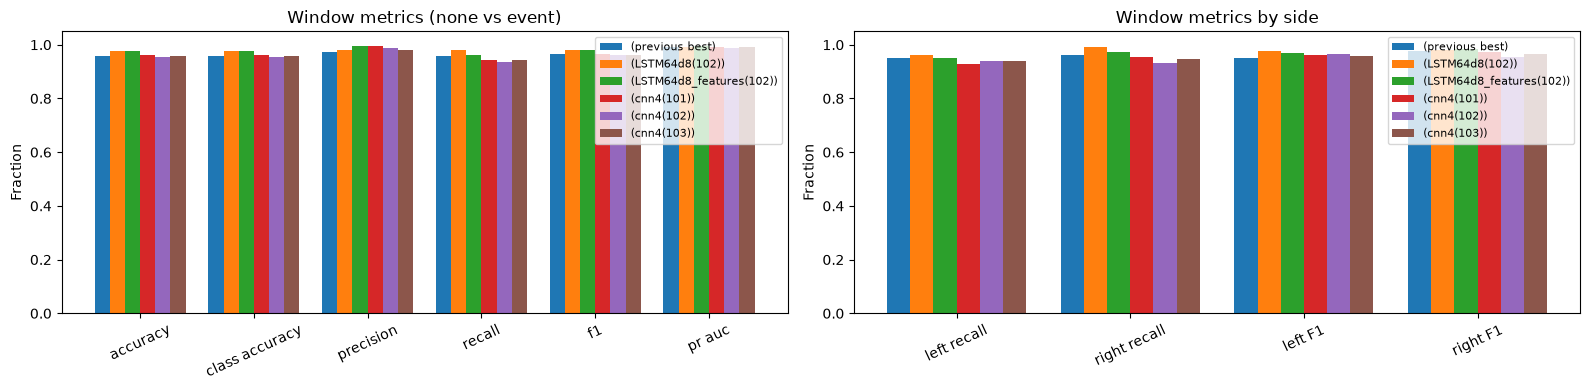

In [5]:
def grouped_bars(ax, table, columns, title, *, scale=1, ylabel='Score'):
    x = np.arange(len(columns))
    width = .8 / len(table)
    for i, (_, row) in enumerate(table.iterrows()):
        values = [row[column] * scale for column in columns]
        ax.bar(x - .4 + width*(i+.5), values, width, label=row['model'])
    ax.set(xticks=x, xticklabels=[name.replace('_', ' ') for name in columns],
           title=title, ylabel=ylabel)
    ax.tick_params(axis='x', rotation=25)
    ax.legend(fontsize=8)

window_metrics = scores[scores.level == 'window'].copy()
overall = window_metrics[window_metrics.side == 'all']
by_side = window_metrics[window_metrics.side != 'all'].copy()
by_side['side_recall'] = by_side.side + ' recall'
by_side['side_f1'] = by_side.side + ' F1'
per_side = pd.concat([
    by_side.pivot(index='model', columns='side_recall', values='recall'),
    by_side.pivot(index='model', columns='side_f1', values='f1')], axis=1).reindex(RUNS).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
grouped_bars(axes[0], overall, ['accuracy', 'class_accuracy', 'precision', 'recall', 'f1', 'pr_auc'],
             'Window metrics (none vs event)', ylabel='Fraction')
grouped_bars(axes[1], per_side, [c for c in per_side if c != 'model'],
             'Window metrics by side', ylabel='Fraction')
for ax in axes: ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [99]:
window_metrics[['model', 'side', 'left_threshold', 'right_threshold', 'n_samples',
                'tp', 'fp', 'fn', 'tn', 'accuracy', 'class_accuracy', 'precision',
                'recall', 'f1', 'pr_auc', 'roc_auc']]  # Full table: window_metrics.

,model,side,left_threshold,right_threshold,n_samples,tp,fp,fn,tn,accuracy,class_accuracy,precision,recall,f1,pr_auc,roc_auc
0,(previous best),all,0.55,0.55,966.0,542,16,24,384.0,0.958592,0.957557,0.971326,0.957597,0.964413,0.991173,0.987602
1,(previous best),left,0.55,0.55,966.0,262,14,14,676.0,0.971014,NaN,0.949275,0.949275,0.949275,0.981065,0.991010
2,(previous best),right,0.55,0.55,966.0,279,3,11,673.0,0.985507,NaN,0.989362,0.962069,0.975524,0.994615,0.997699
9,(LSTM64d8(102)),all,0.60,0.55,966.0,554,10,12,390.0,0.977226,0.976190,0.982270,0.978799,0.980531,0.991224,0.990897
10,(LSTM64d8(102)),left,0.60,0.55,966.0,265,1,11,689.0,0.987578,NaN,0.996241,0.960145,0.977860,0.991523,0.995285
11,(LSTM64d8(102)),right,0.60,0.55,966.0,288,10,2,666.0,0.987578,NaN,0.966443,0.993103,0.979592,0.985403,0.996297
18,(LSTM64d8_features(102)),all,0.65,0.51,966.0,545,2,21,398.0,0.976190,0.975155,0.996344,0.962898,0.979335,0.995562,0.993843
19,(LSTM64d8_features(102)),left,0.65,0.51,966.0,262,2,14,688.0,0.983437,NaN,0.992424,0.949275,0.970370,0.988806,0.993389
20,(LSTM64d8_features(102)),right,0.65,0.51,966.0,282,1,8,675.0,0.990683,NaN,0.996466,0.972414,0.984293,0.996631,0.998699
27,(cnn4(101)),all,0.60,0.70,966.0,533,3,33,397.0,0.962733,0.962733,0.994403,0.941696,0.967332,0.991954,0.989227


## Frame diagnostics
These per-frame values depend on the selected thresholds, except PR-AUC/ROC-AUC. Frames near the same physical event are correlated; streaming event results below are the primary product metrics.

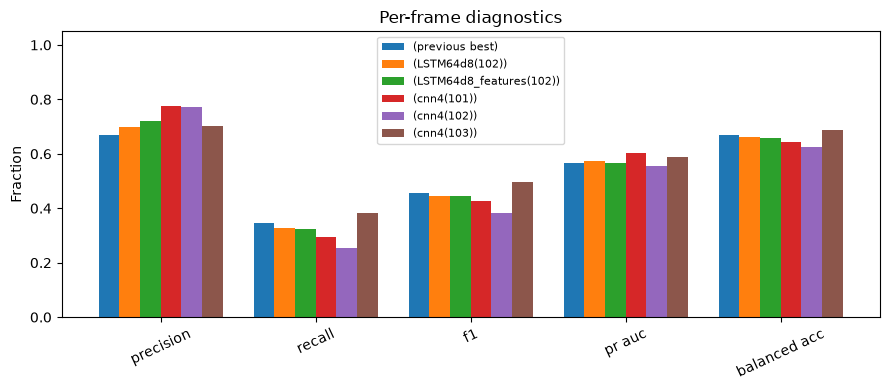

In [100]:
frame_metrics = scores[scores.level == 'frame'].copy()
fig, ax = plt.subplots(figsize=(9, 4))
grouped_bars(ax, frame_metrics[frame_metrics.side == 'all'],
             ['precision', 'recall', 'f1', 'pr_auc', 'balanced_acc'],
             'Per-frame diagnostics', ylabel='Fraction')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [101]:
frame_metrics[frame_metrics['side'] == 'all'][['model', 'side', 'precision', 'recall', 'f1', 'pr_auc', 'roc_auc',
               'n_samples', 'tp', 'fp', 'fn']]  # Full table: frame_metrics.

,model,side,precision,recall,f1,pr_auc,roc_auc,n_samples,tp,fp,fn
3,(previous best),all,0.670430,0.344691,0.455298,0.564859,0.956183,292646.0,4097,2014,7789
12,(LSTM64d8(102)),all,0.696839,0.326434,0.444597,0.574417,0.960952,292646.0,3880,1688,8006
21,(LSTM64d8_features(102)),all,0.720503,0.323153,0.446187,0.567898,0.951200,292646.0,3841,1490,8045
30,(cnn4(101)),all,0.775067,0.293959,0.426254,0.602314,0.950620,292646.0,3494,1014,8392
39,(cnn4(102)),all,0.771706,0.254249,0.382483,0.554313,0.946048,292646.0,3022,894,8864
48,(cnn4(103)),all,0.701369,0.383729,0.496057,0.590044,0.957967,292646.0,4561,1942,7325


## Streaming event detection
Event matching is class-aware, one-to-one, and uses the **actual alarm-emission frame**. FP/min counts unmatched alarms over all validation minutes, including early and wrong-side alarms. The selected operating point can differ per model even though its selection mode is the same.

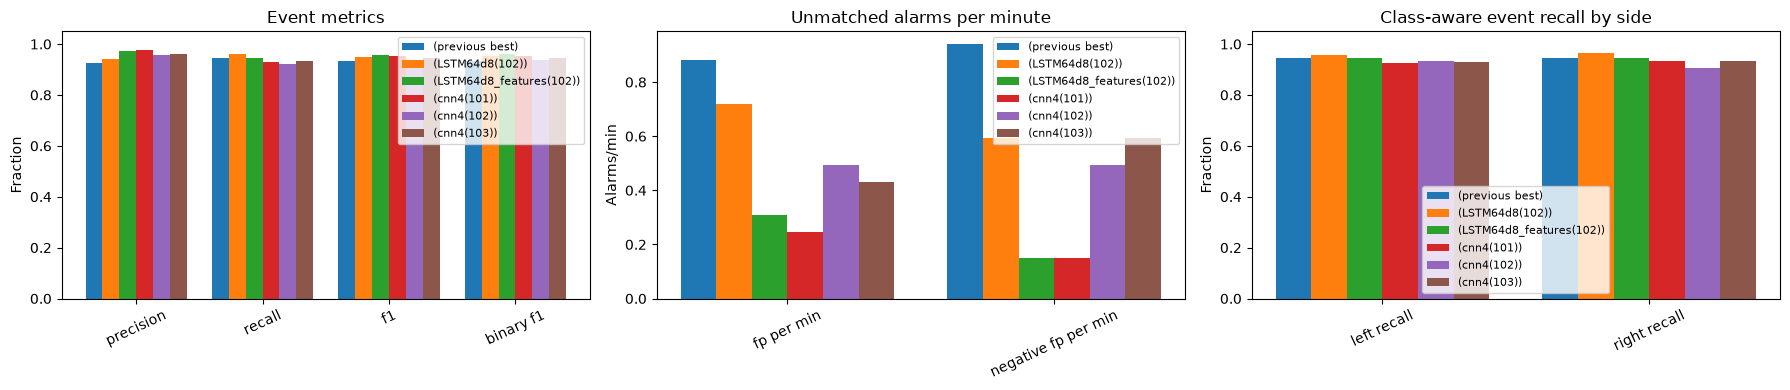

In [102]:
event_metrics = scores[scores.level == 'event'].copy()
event_overall = event_metrics[event_metrics.side == 'all']
event_side = event_metrics[event_metrics.side != 'all'].copy()
event_side['side_recall'] = event_side.side + ' recall'
side_recall = event_side.pivot(index='model', columns='side_recall', values='recall').reindex(RUNS).reset_index()
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
grouped_bars(axes[0], event_overall, ['precision', 'recall', 'f1', 'binary_f1'],
             'Event metrics', ylabel='Fraction')
grouped_bars(axes[1], event_overall, ['fp_per_min', 'negative_fp_per_min'],
             'Unmatched alarms per minute', ylabel='Alarms/min')
grouped_bars(axes[2], side_recall, [c for c in side_recall if c != 'model'],
             'Class-aware event recall by side', ylabel='Fraction')
axes[0].set_ylim(0, 1.05)
axes[2].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [103]:
event_metrics[event_metrics['side'] == 'all'][['model', 'side', 'tp', 'fp', 'fn', 'precision', 'recall', 'f1',
               'binary_f1', 'fp_per_min', 'negative_fp_per_min',
               'left_threshold', 'right_threshold']]  # Full table: event_metrics.

,model,side,tp,fp,fn,precision,recall,f1,binary_f1,fp_per_min,negative_fp_per_min,left_threshold,right_threshold
6,(previous best),all,535,43,31,0.925606,0.945230,0.935315,0.935315,0.881611,0.940710,0.55,0.55
15,(LSTM64d8(102)),all,544,35,22,0.939551,0.961131,0.950218,0.951965,0.717591,0.594133,0.60,0.55
24,(LSTM64d8_features(102)),all,535,15,31,0.972727,0.945230,0.958781,0.960573,0.307539,0.148533,0.65,0.51
33,(cnn4(101)),all,526,12,40,0.977695,0.929329,0.952899,0.952899,0.246031,0.148533,0.60,0.70
42,(cnn4(102)),all,521,24,45,0.955963,0.920495,0.937894,0.937894,0.492062,0.495111,0.70,0.65
51,(cnn4(103)),all,528,21,38,0.961749,0.932862,0.947085,0.947085,0.430554,0.594133,0.60,0.50


## Alarm latency
Deadline recall is the fraction of **all annotated events** detected before X frames (misses remain in the denominator). Mean/median/p90 latency includes matched events only and can be misleading if recall is low.

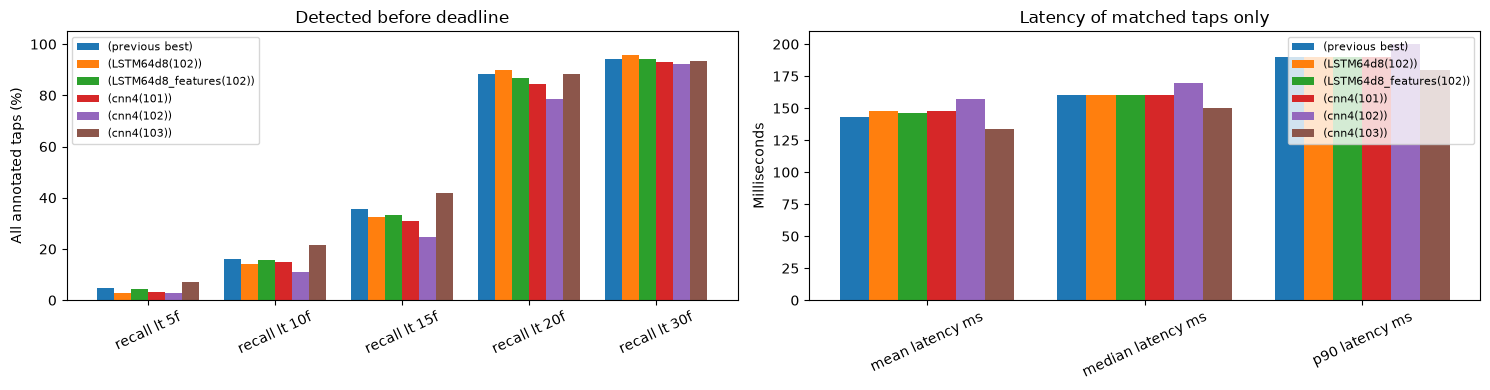

In [104]:
latency_metrics = event_overall[['model', 'left_threshold', 'right_threshold',
                                 'recall_lt_5f', 'recall_lt_10f', 'recall_lt_15f',
                                 'recall_lt_20f', 'recall_lt_30f', 'mean_latency_ms',
                                 'median_latency_ms', 'p90_latency_ms', 'tp', 'fn']].copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
grouped_bars(axes[0], latency_metrics,
             ['recall_lt_5f', 'recall_lt_10f', 'recall_lt_15f', 'recall_lt_20f', 'recall_lt_30f'],
             'Detected before deadline', scale=100, ylabel='All annotated taps (%)')
grouped_bars(axes[1], latency_metrics,
             ['mean_latency_ms', 'median_latency_ms', 'p90_latency_ms'],
             'Latency of matched taps only', ylabel='Milliseconds')
axes[0].set_ylim(0, 105)
plt.tight_layout()
plt.show()

In [105]:
latency_metrics  # Filter model and compare recall/latency at the same deadline.

,model,left_threshold,right_threshold,recall_lt_5f,recall_lt_10f,recall_lt_15f,recall_lt_20f,recall_lt_30f,mean_latency_ms,median_latency_ms,p90_latency_ms,tp,fn
6,(previous best),0.55,0.55,0.047703,0.162544,0.355124,0.883392,0.941696,142.785047,160.0,190.0,535,31
15,(LSTM64d8(102)),0.60,0.55,0.030035,0.143110,0.323322,0.897527,0.959364,147.463235,160.0,190.0,544,22
24,(LSTM64d8_features(102)),0.65,0.51,0.042403,0.157244,0.332155,0.867491,0.941696,146.317757,160.0,190.0,535,31
33,(cnn4(101)),0.60,0.70,0.033569,0.150177,0.309187,0.844523,0.929329,147.566540,160.0,190.0,526,40
42,(cnn4(102)),0.70,0.65,0.026502,0.111307,0.247350,0.786219,0.920495,156.852207,170.0,200.0,521,45
51,(cnn4(103)),0.60,0.50,0.070671,0.215548,0.416961,0.883392,0.932862,133.541667,150.0,180.0,528,38


## Recording types and individual files
Rows use the same selected policy and left/right thresholds as the event and window plots. Negative-only types have undefined event recall; their FP/min and false-positive window rates are the useful metrics. Grouped by type, every value is pooled over its files (not an average of file percentages). Some types contain only one file.

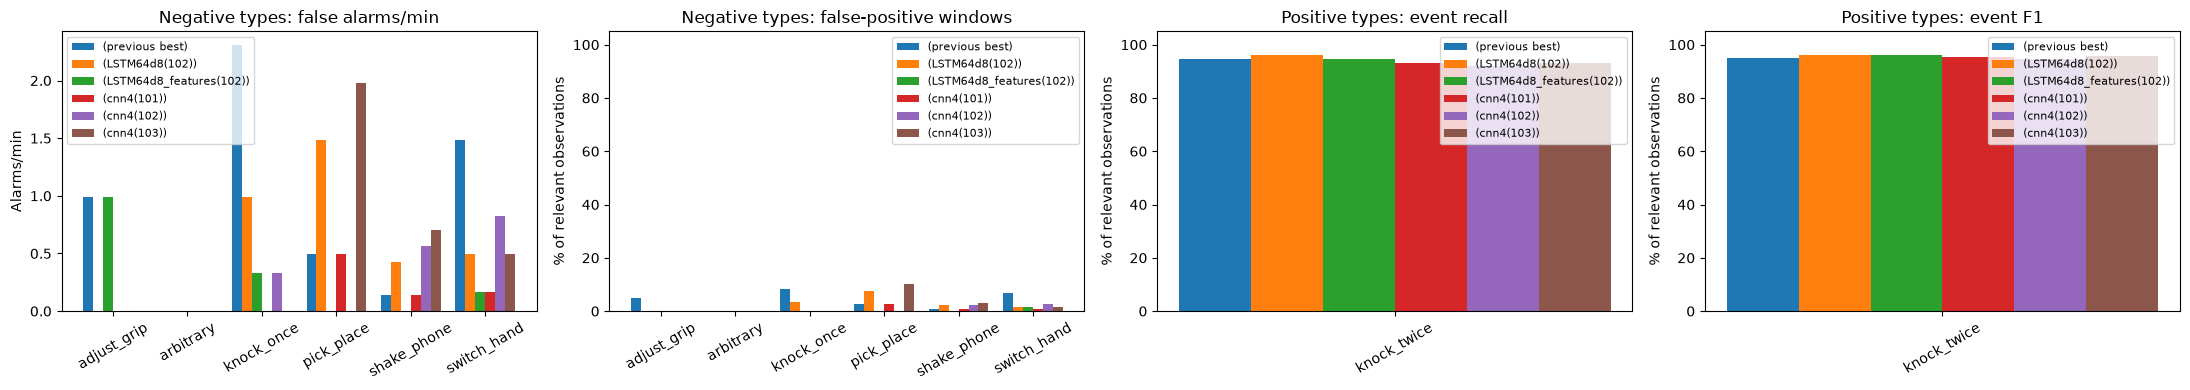

In [106]:
type_comparison = type_scores.copy()
negative = type_comparison[type_comparison.n_true_events == 0]
positive = type_comparison[type_comparison.n_true_events > 0]
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
for ax, subset, metric, title, scale in [
        (axes[0], negative, 'event_fp_per_min', 'Negative types: false alarms/min', 1),
        (axes[1], negative, 'window_false_positive_rate', 'Negative types: false-positive windows', 100),
        (axes[2], positive, 'event_recall', 'Positive types: event recall', 100),
        (axes[3], positive, 'event_f1', 'Positive types: event F1', 100)]:
    x = sorted(subset.recording_type.unique())
    width = .8 / len(RUNS)
    for i, label in enumerate(RUNS):
        rows = subset[subset.model == label].set_index('recording_type').reindex(x)
        ax.bar(np.arange(len(x)) - .4 + width*(i+.5), rows[metric] * scale, width, label=label)
    ax.set(xticks=np.arange(len(x)), xticklabels=x, title=title)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)
axes[0].set_ylabel('Alarms/min')
for ax in axes[1:]: ax.set(ylabel='% of relevant observations', ylim=(0, 105))
plt.tight_layout()
plt.show()

In [107]:
type_comparison[['model', 'recording_type', 'recordings', 'n_windows', 'n_true_events',
                 'event_tp', 'event_fp', 'event_fn', 'event_f1', 'event_fp_per_min',
                 'event_left_recall', 'event_right_recall', 'window_accuracy',
                 'window_false_positive_rate']]  # Full table: type_comparison.

,model,recording_type,recordings,n_windows,n_true_events,event_tp,event_fp,event_fn,event_f1,event_fp_per_min,event_left_recall,event_right_recall,window_accuracy,window_false_positive_rate
0,(previous best),adjust_grip,1,20,0,0,1,0,0.000000,0.989936,NaN,NaN,0.950000,0.050000
1,(previous best),arbitrary,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
2,(previous best),knock_once,3,60,0,0,7,0,0.000000,2.311375,NaN,NaN,0.916667,0.083333
3,(previous best),knock_twice,29,566,566,535,24,31,0.951111,0.839841,0.945652,0.944828,0.955830,NaN
4,(previous best),pick_place,2,40,0,0,1,0,0.000000,0.494845,NaN,NaN,0.975000,0.025000
5,(previous best),shake_phone,7,140,0,0,1,0,0.000000,0.141469,NaN,NaN,0.992857,0.007143
6,(previous best),switch_hand,6,120,0,0,9,0,0.000000,1.485394,NaN,NaN,0.933333,0.066667
7,(LSTM64d8(102)),adjust_grip,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
8,(LSTM64d8(102)),arbitrary,1,20,0,0,0,0,NaN,0.000000,NaN,NaN,1.000000,0.000000
9,(LSTM64d8(102)),knock_once,3,60,0,0,3,0,0.000000,0.990589,NaN,NaN,0.966667,0.033333


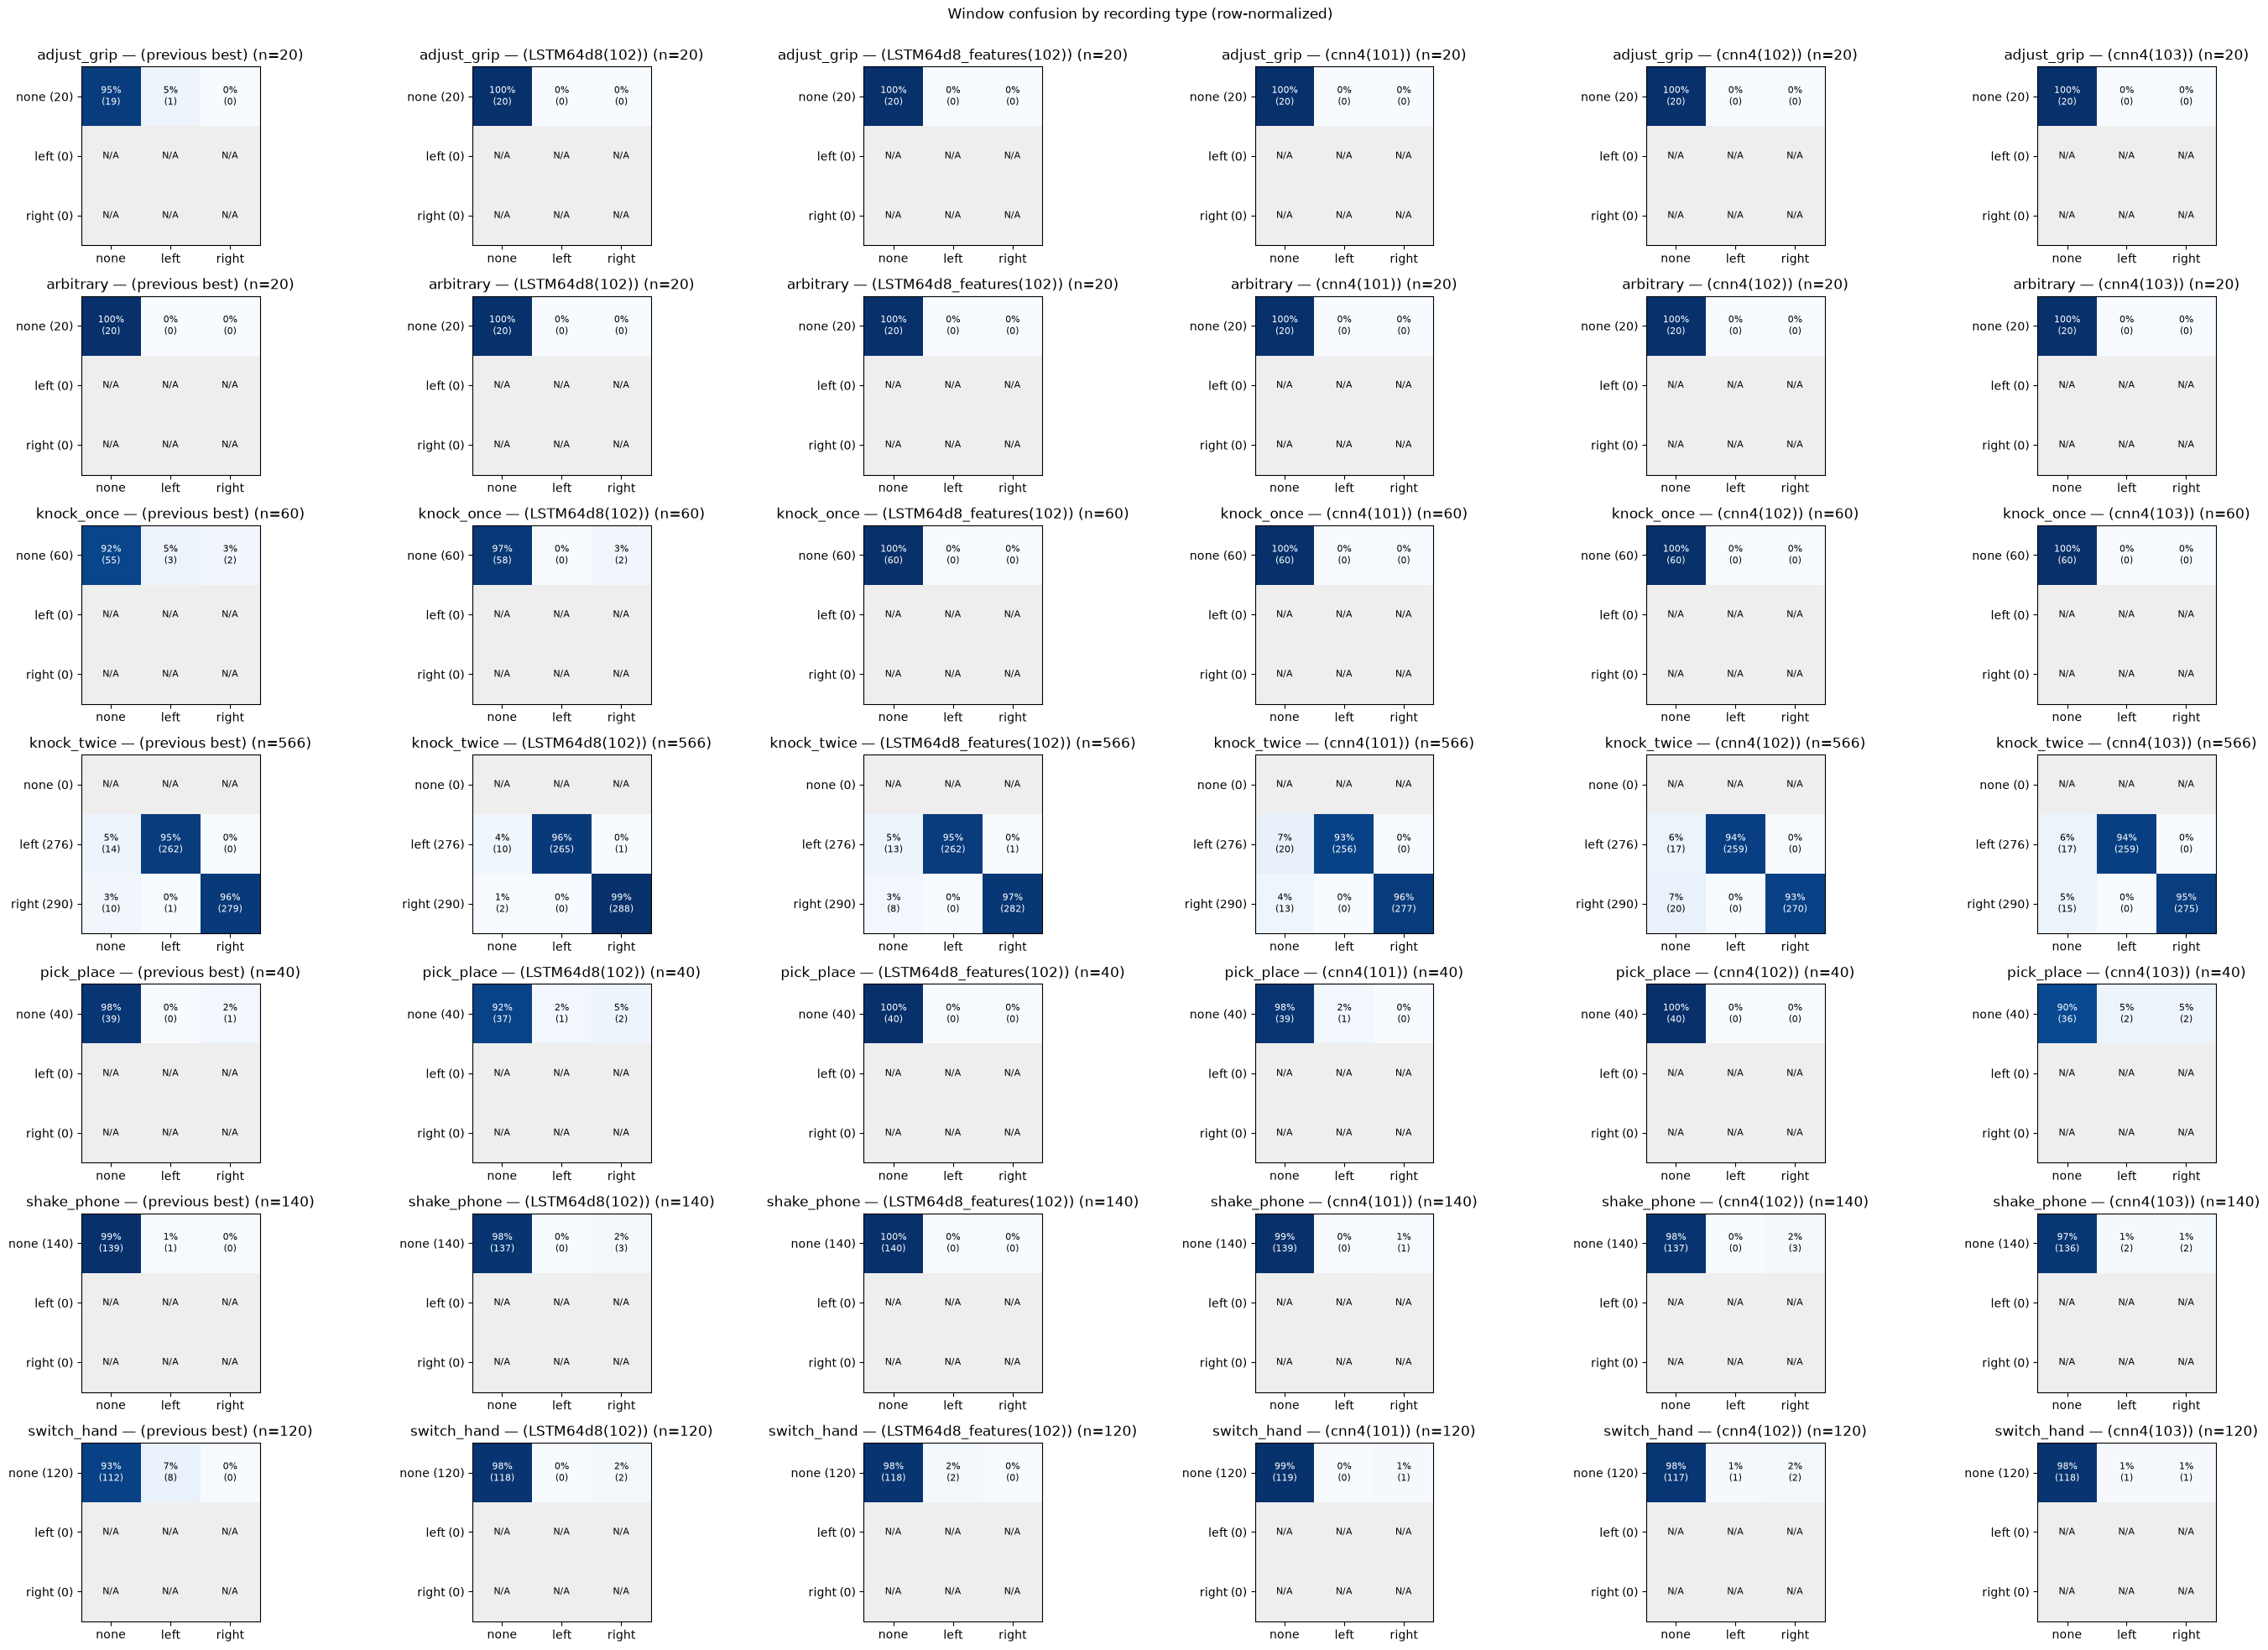

In [108]:
from matplotlib.colors import Normalize
confusion_rows = []
recording_types = sorted(expected_types)
fig, axes = plt.subplots(len(recording_types), len(RUNS),
                         figsize=(4.8*len(RUNS), 2.8*len(recording_types)), squeeze=False)
colors = plt.get_cmap('Blues').copy()
colors.set_bad('#eeeeee')
for i, recording_type in enumerate(recording_types):
    for j, model_name in enumerate(RUNS):
        row = type_comparison[(type_comparison.recording_type == recording_type) &
                              (type_comparison.model == model_name)].iloc[0]
        cm = np.array([[int(row[f'cm_{t}{p}']) for p in range(3)] for t in range(3)])
        totals = cm.sum(axis=1)
        fractions = np.divide(cm, totals[:, None], out=np.full((3, 3), np.nan),
                              where=totals[:, None] > 0)
        ax = axes[i, j]
        ax.imshow(np.ma.masked_invalid(fractions), cmap=colors, norm=Normalize(0, 1))
        ax.set(title=f'{recording_type} — {model_name} (n={cm.sum()})',
               xticks=range(3), xticklabels=('none', 'left', 'right'),
               yticks=range(3), yticklabels=[f'{name} ({n})' for name, n in
                                        zip(('none', 'left', 'right'), totals)])
        for t, true_class in enumerate(('none', 'left', 'right')):
            for p, predicted_class in enumerate(('none', 'left', 'right')):
                ax.text(p, t, f'{fractions[t, p]:.0%}\n({cm[t, p]})' if totals[t] else 'N/A',
                        ha='center', va='center', fontsize=8,
                        color='white' if totals[t] and fractions[t, p] > .55 else 'black')
                confusion_rows.append(dict(model=model_name, recording_type=recording_type,
                                           true_class=true_class, predicted_class=predicted_class,
                                           count=int(cm[t, p]), true_count=int(totals[t]),
                                           row_fraction=fractions[t, p]))
fig.suptitle('Window confusion by recording type (row-normalized)', y=1.001)
plt.tight_layout()
plt.show()
type_confusion_comparison = pd.DataFrame(confusion_rows)

In [109]:
type_confusion_comparison  # N/A rows have no observed examples of that true class.

,model,recording_type,true_class,predicted_class,count,true_count,row_fraction
0,(previous best),adjust_grip,none,none,19,20,0.95
1,(previous best),adjust_grip,none,left,1,20,0.05
2,(previous best),adjust_grip,none,right,0,20,0.00
3,(previous best),adjust_grip,left,none,0,0,NaN
4,(previous best),adjust_grip,left,left,0,0,NaN
...,...,...,...,...,...,...,...
373,(cnn4(103)),switch_hand,left,left,0,0,NaN
374,(cnn4(103)),switch_hand,left,right,0,0,NaN
375,(cnn4(103)),switch_hand,right,none,0,0,NaN
376,(cnn4(103)),switch_hand,right,left,0,0,NaN


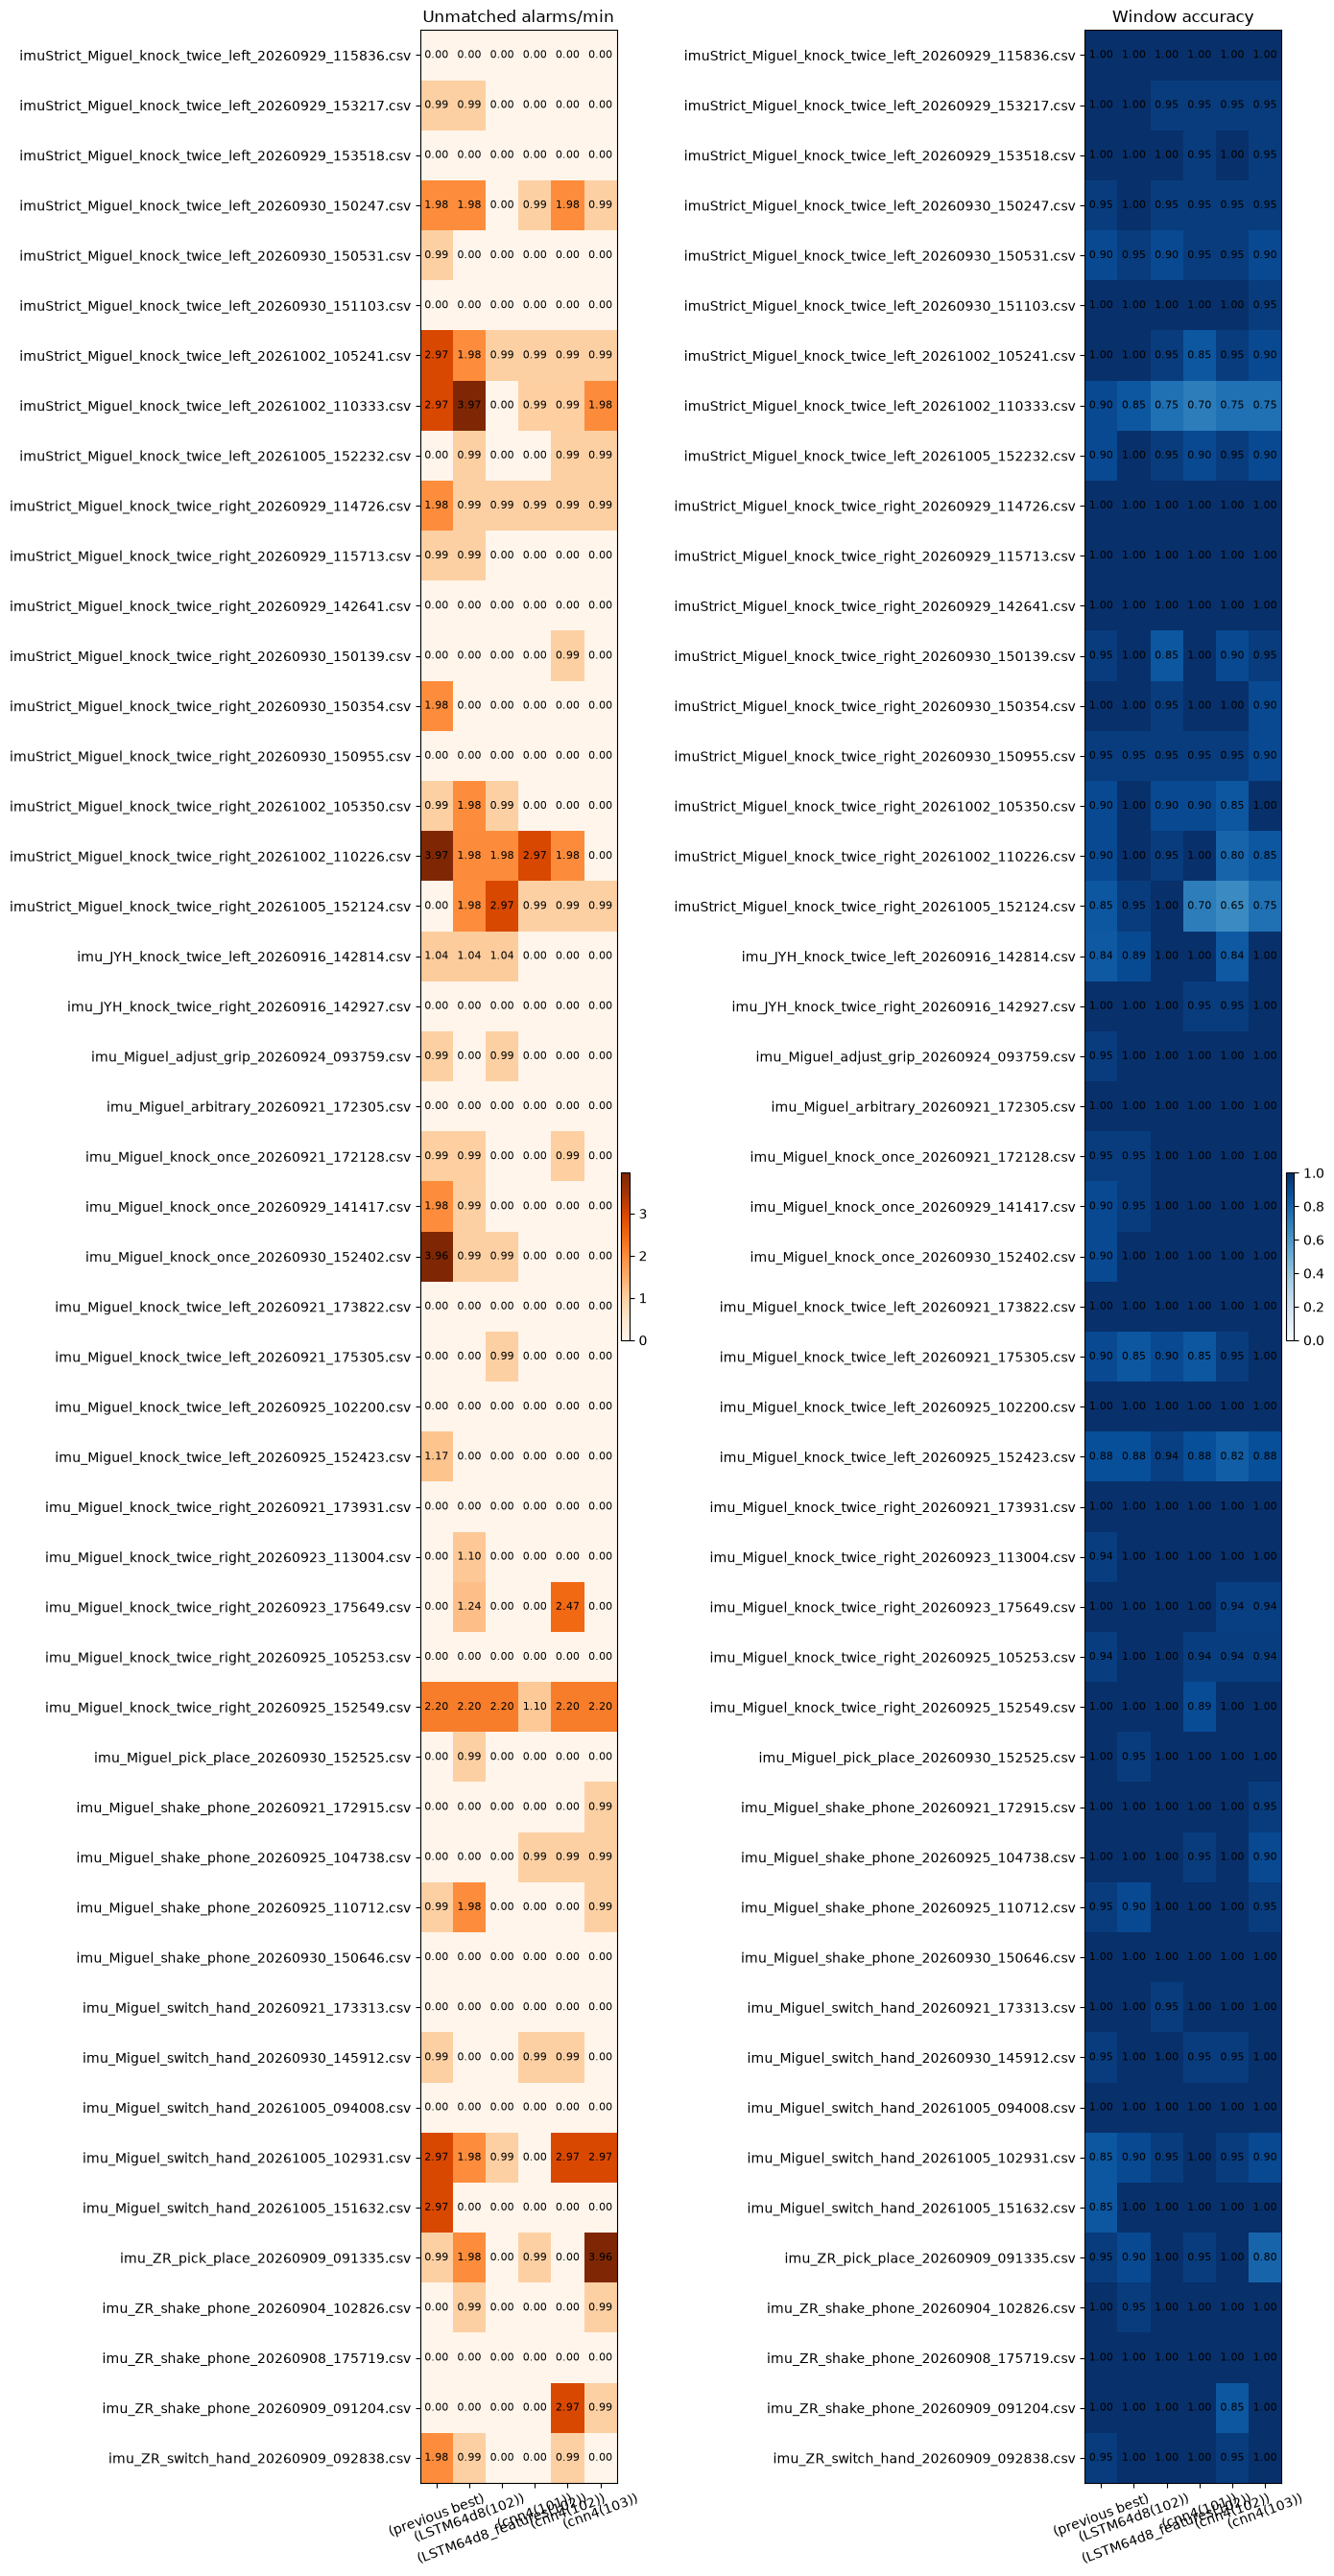

In [110]:
recording_comparison = file_scores.copy()
files = sorted(recording_comparison.file.unique())
fig, axes = plt.subplots(1, 2, figsize=(14, max(6, .55*len(files))))
for ax, field, label, cmap in [
        (axes[0], 'event_fp_per_min', 'Unmatched alarms/min', 'Oranges'),
        (axes[1], 'window_accuracy', 'Window accuracy', 'Blues')]:
    table = recording_comparison.pivot(index='file', columns='model', values=field).reindex(
        index=files, columns=list(RUNS))
    data = table.to_numpy(dtype=float)
    im = ax.imshow(data, aspect='auto', cmap=cmap, vmin=0, vmax=1 if field == 'window_accuracy' else None)
    ax.set(yticks=np.arange(len(files)), yticklabels=files, xticks=np.arange(len(RUNS)),
           xticklabels=list(RUNS), title=label)
    ax.tick_params(axis='x', rotation=20)
    for i in range(len(files)):
        for j in range(len(RUNS)):
            ax.text(j, i, f'{data[i, j]:.2f}',
                    ha='center', va='center', color='black', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=.04, pad=.02)
plt.tight_layout()
plt.show()

In [111]:
recording_comparison[['model', 'file', 'recording_type', 'n_windows',
                      'n_true_events', 'event_tp', 'event_fp', 'event_fn',
                      'window_fp', 'window_fn', 'event_fp_per_min', 'minutes']]  # Full table: recording_comparison.

,model,file,recording_type,n_windows,n_true_events,event_tp,event_fp,event_fn,window_fp,window_fn,event_fp_per_min,minutes
0,(previous best),imuStrict_Miguel_knock_twice_left_20260929_115...,knock_twice,20,20,20,0,0,0,0,0.000000,1.010500
1,(previous best),imuStrict_Miguel_knock_twice_left_20260929_153...,knock_twice,20,20,20,1,0,0,0,0.989936,1.010167
2,(previous best),imuStrict_Miguel_knock_twice_left_20260929_153...,knock_twice,20,20,20,0,0,0,0,0.000000,1.010667
3,(previous best),imuStrict_Miguel_knock_twice_left_20260930_150...,knock_twice,20,20,19,2,1,0,1,1.979218,1.010500
4,(previous best),imuStrict_Miguel_knock_twice_left_20260930_150...,knock_twice,20,20,18,1,2,0,2,0.990426,1.009667
...,...,...,...,...,...,...,...,...,...,...,...,...
289,(cnn4(103)),imu_ZR_pick_place_20260909_091335.csv,pick_place,20,0,0,4,0,4,0,3.959089,1.010333
290,(cnn4(103)),imu_ZR_shake_phone_20260904_102826.csv,shake_phone,20,0,0,1,0,0,0,0.991244,1.008833
291,(cnn4(103)),imu_ZR_shake_phone_20260908_175719.csv,shake_phone,20,0,0,0,0,0,0,0.000000,1.009000
292,(cnn4(103)),imu_ZR_shake_phone_20260909_091204.csv,shake_phone,20,0,0,1,0,0,0,0.989446,1.010667


## Inspect individual validation examples (current recordings)
The saved exports above contain per-recording totals, but not individual segment predictions or probability traces. The next cell replays each selected `best.pt` on **the current validation files** at its saved left/right thresholds, with the same window fitting, continuous causal inference, class-aware event matching, and alarm policy as the evaluator. It does not tune thresholds. `example_data_status` shows whether today's raw CSVs, label text files, and exclusion registry still match the original exports. If not, the detailed tables below describe *current-data replay* and must not be mixed with the historical exported totals above.

`segment_scores` and `recording_scores` are long-form filterable tables; `segment_matrix` and `recording_matrix` put each model in its own column group. Segment IDs are the CSV's `segment_index` (not window row numbers). Event TP/FP/FN use one-to-one matching on the **whole recording** before attribution to a segment; `too_early_fp` counts unmatched alarms emitted too early for their nearest tap, while `wrong_side_fp` is an unmatched alarm that matched in the side-agnostic check. Window classification is separate from alarm matching. Excluded segments and unlabeled windows are not scored.


In [112]:
import importlib
import sys
sys.path.insert(0, str(ROOT))
import torch
from notebooks_analysis import model_comparison_examples

# Reload so rerunning this cell uses the current replay implementation.
importlib.reload(model_comparison_examples)
comparison_matrix = model_comparison_examples.comparison_matrix
plot_example = model_comparison_examples.plot_example
replay_examples = model_comparison_examples.replay_examples

torch.set_num_threads(2)
detail_points = operating_points.merge(comparison_sources[[
    'model', 'folder', 'checkpoint_path', 'evaluation_data',
    'evaluation_labels', 'evaluation_seed',
]],
                                       on='model', validate='one_to_one')
example_recordings, example_traces, segment_scores, recording_scores, alarm_details, example_data_status = (
    replay_examples(ROOT, detail_points)
)
display(example_data_status)
print('Detailed replay:', len(segment_scores), 'model/segment rows,',
      len(recording_scores), 'model/recording rows,', len(alarm_details), 'alarms')

  Excluding session(s) [4] from imu_JYH_knock_twice_left_20260916_142814.csv
  Excluding session(s) [3, 5, 7] from imu_Miguel_knock_twice_left_20260925_152423.csv
  Excluding session(s) [17, 18] from imu_Miguel_knock_twice_right_20260923_113004.csv
  Excluding session(s) [4, 8, 12, 19] from imu_Miguel_knock_twice_right_20260923_175649.csv
  Excluding session(s) [18, 20] from imu_Miguel_knock_twice_right_20260925_105253.csv
  Excluding session(s) [10, 17] from imu_Miguel_knock_twice_right_20260925_152549.csv


,model,split,export_validation_sha256,current_validation_sha256,matches_export
0,(previous best),valid,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,True
1,(LSTM64d8(102)),valid,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,True
2,(LSTM64d8_features(102)),valid,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,True
3,(cnn4(101)),valid,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,True
4,(cnn4(102)),valid,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,True
5,(cnn4(103)),valid,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,b49802fe63f23bd6961fe2ef153b79cecd339661c33060...,True


Detailed replay: 5796 model/segment rows, 294 model/recording rows, 3339 alarms


### Find difficult segments and recordings
Filter `segment_scores.query("recording_type == 'knock_twice' and event_fn > 0")` for missed double taps or `segment_scores.query('too_early_fp > 0 or wrong_side_fp > 0')` for premature/wrong-side alarms. `alarm_details` gives each alarm's global emission/peak frame, closest annotation, matched status, and segment ID. `recording_scores` includes both knock-twice recordings and negative-only activity; its `event_fp_per_min` uses the sum of **included** segment durations. Edit the displayed slices or filter `segment_matrix.loc[('filename.csv', 8)]` / `recording_matrix.loc['filename.csv']` to see every model together.


In [113]:

    

segment_matrix = comparison_matrix(segment_scores, ['file', 'segment_index'],
    ['window_true', 'window_pred', 'window_correct', 'window_fp', 'window_fn',
     'p_left_max', 'p_right_max', 'event_tp', 'event_fp', 'event_fn',
     'too_early_fp', 'wrong_side_fp', 'latency_frames'])
recording_matrix = comparison_matrix(recording_scores, ['file'],
    ['recording_type', 'minutes', 'n_windows', 'window_accuracy', 'window_fp', 'window_fn',
     'n_true_events', 'event_tp', 'event_fp', 'event_fn', 'too_early_fp',
     'wrong_side_fp', 'event_fp_per_min'])
segment_difficulty = segment_scores.groupby(['file', 'segment_index', 'recording_type'],
    as_index=False).agg(models_missing=('event_fn', lambda x: (x > 0).sum()),
                        models_false_alarm=('event_fp', lambda x: (x > 0).sum()),
                        models_window_wrong=('window_correct', lambda x: (x == False).sum()),
                        too_early_fp=('too_early_fp', 'sum'), wrong_side_fp=('wrong_side_fp', 'sum'))
print('Hard double-tap segments (one row per CSV segment):')
with pd.option_context('display.max_colwidth', None):
    display(segment_difficulty.query("recording_type == 'knock_twice'")
        .sort_values(['models_missing', 'too_early_fp', 'models_false_alarm'],
                     ascending=False).head(25))
print('Hard recordings (one row per model/recording):')
with pd.option_context('display.max_colwidth', None):
    display(recording_scores.sort_values(['event_fp_per_min', 'event_fn'], ascending=False)
        [['model', 'file', 'recording_type', 'n_true_events', 'event_tp', 'event_fp',
          'event_fn', 'too_early_fp', 'window_fp', 'event_fp_per_min']].head(25))

Hard double-tap segments (one row per CSV segment):


,file,segment_index,recording_type,models_missing,models_false_alarm,models_window_wrong,too_early_fp,wrong_side_fp
655,imu_Miguel_knock_twice_right_20260925_152549.csv,8,knock_twice,6,6,0,6,0
122,imuStrict_Miguel_knock_twice_left_20261002_105241.csv,3,knock_twice,6,5,0,0,0
320,imuStrict_Miguel_knock_twice_right_20261002_110226.csv,1,knock_twice,6,5,1,0,0
652,imu_Miguel_knock_twice_right_20260925_152549.csv,5,knock_twice,6,5,1,0,0
146,imuStrict_Miguel_knock_twice_left_20261002_110333.csv,7,knock_twice,6,1,5,0,0
80,imuStrict_Miguel_knock_twice_left_20260930_150531.csv,1,knock_twice,6,0,6,0,0
141,imuStrict_Miguel_knock_twice_left_20261002_110333.csv,2,knock_twice,6,0,6,0,0
148,imuStrict_Miguel_knock_twice_left_20261002_110333.csv,9,knock_twice,6,0,6,0,0
299,imuStrict_Miguel_knock_twice_right_20260930_150955.csv,20,knock_twice,6,0,6,0,0
566,imu_Miguel_knock_twice_left_20260925_152423.csv,11,knock_twice,6,0,6,0,0


Hard recordings (one row per model/recording):


,model,file,recording_type,n_true_events,event_tp,event_fp,event_fn,too_early_fp,window_fp,event_fp_per_min
261,(previous best),imuStrict_Miguel_knock_twice_right_20261002_110226.csv,knock_twice,20,15,4,5,0,0,3.965631
7,(LSTM64d8(102)),imuStrict_Miguel_knock_twice_left_20261002_110333.csv,knock_twice,20,17,4,3,0,0,3.965631
240,(cnn4(103)),imu_ZR_pick_place_20260909_091335.csv,pick_place,0,0,4,0,0,4,3.959089
269,(previous best),imu_Miguel_knock_once_20260930_152402.csv,knock_once,0,0,4,0,0,2,3.958436
114,(cnn4(101)),imuStrict_Miguel_knock_twice_right_20261002_110226.csv,knock_twice,20,17,3,3,0,0,2.974223
252,(previous best),imuStrict_Miguel_knock_twice_left_20261002_110333.csv,knock_twice,20,17,3,3,0,0,2.974223
189,(cnn4(102)),imu_Miguel_switch_hand_20261005_102931.csv,switch_hand,0,0,3,0,0,1,2.971768
238,(cnn4(103)),imu_Miguel_switch_hand_20261005_102931.csv,switch_hand,0,0,3,0,0,2,2.971768
287,(previous best),imu_Miguel_switch_hand_20261005_102931.csv,switch_hand,0,0,3,0,0,3,2.971768
251,(previous best),imuStrict_Miguel_knock_twice_left_20261002_105241.csv,knock_twice,20,19,3,1,0,0,2.971278


### Aligned recording/segment inspection
Choose a `file` and optionally a `segment_index` from the tables. The top row shows acceleration deviation and gyro magnitude from the original CSV; the following rows show each model's left/right probabilities, dotted operating thresholds, annotated second taps (dashed), and emitted alarms (triangles; red edges are unmatched alarms). All rows share the original recording's time axis. Use `REVIEW_SEGMENT = None` to inspect an entire recording.


,model,file,segment_index,window_true,window_pred,event_tp,event_fp,event_fn,too_early_fp,latency_frames


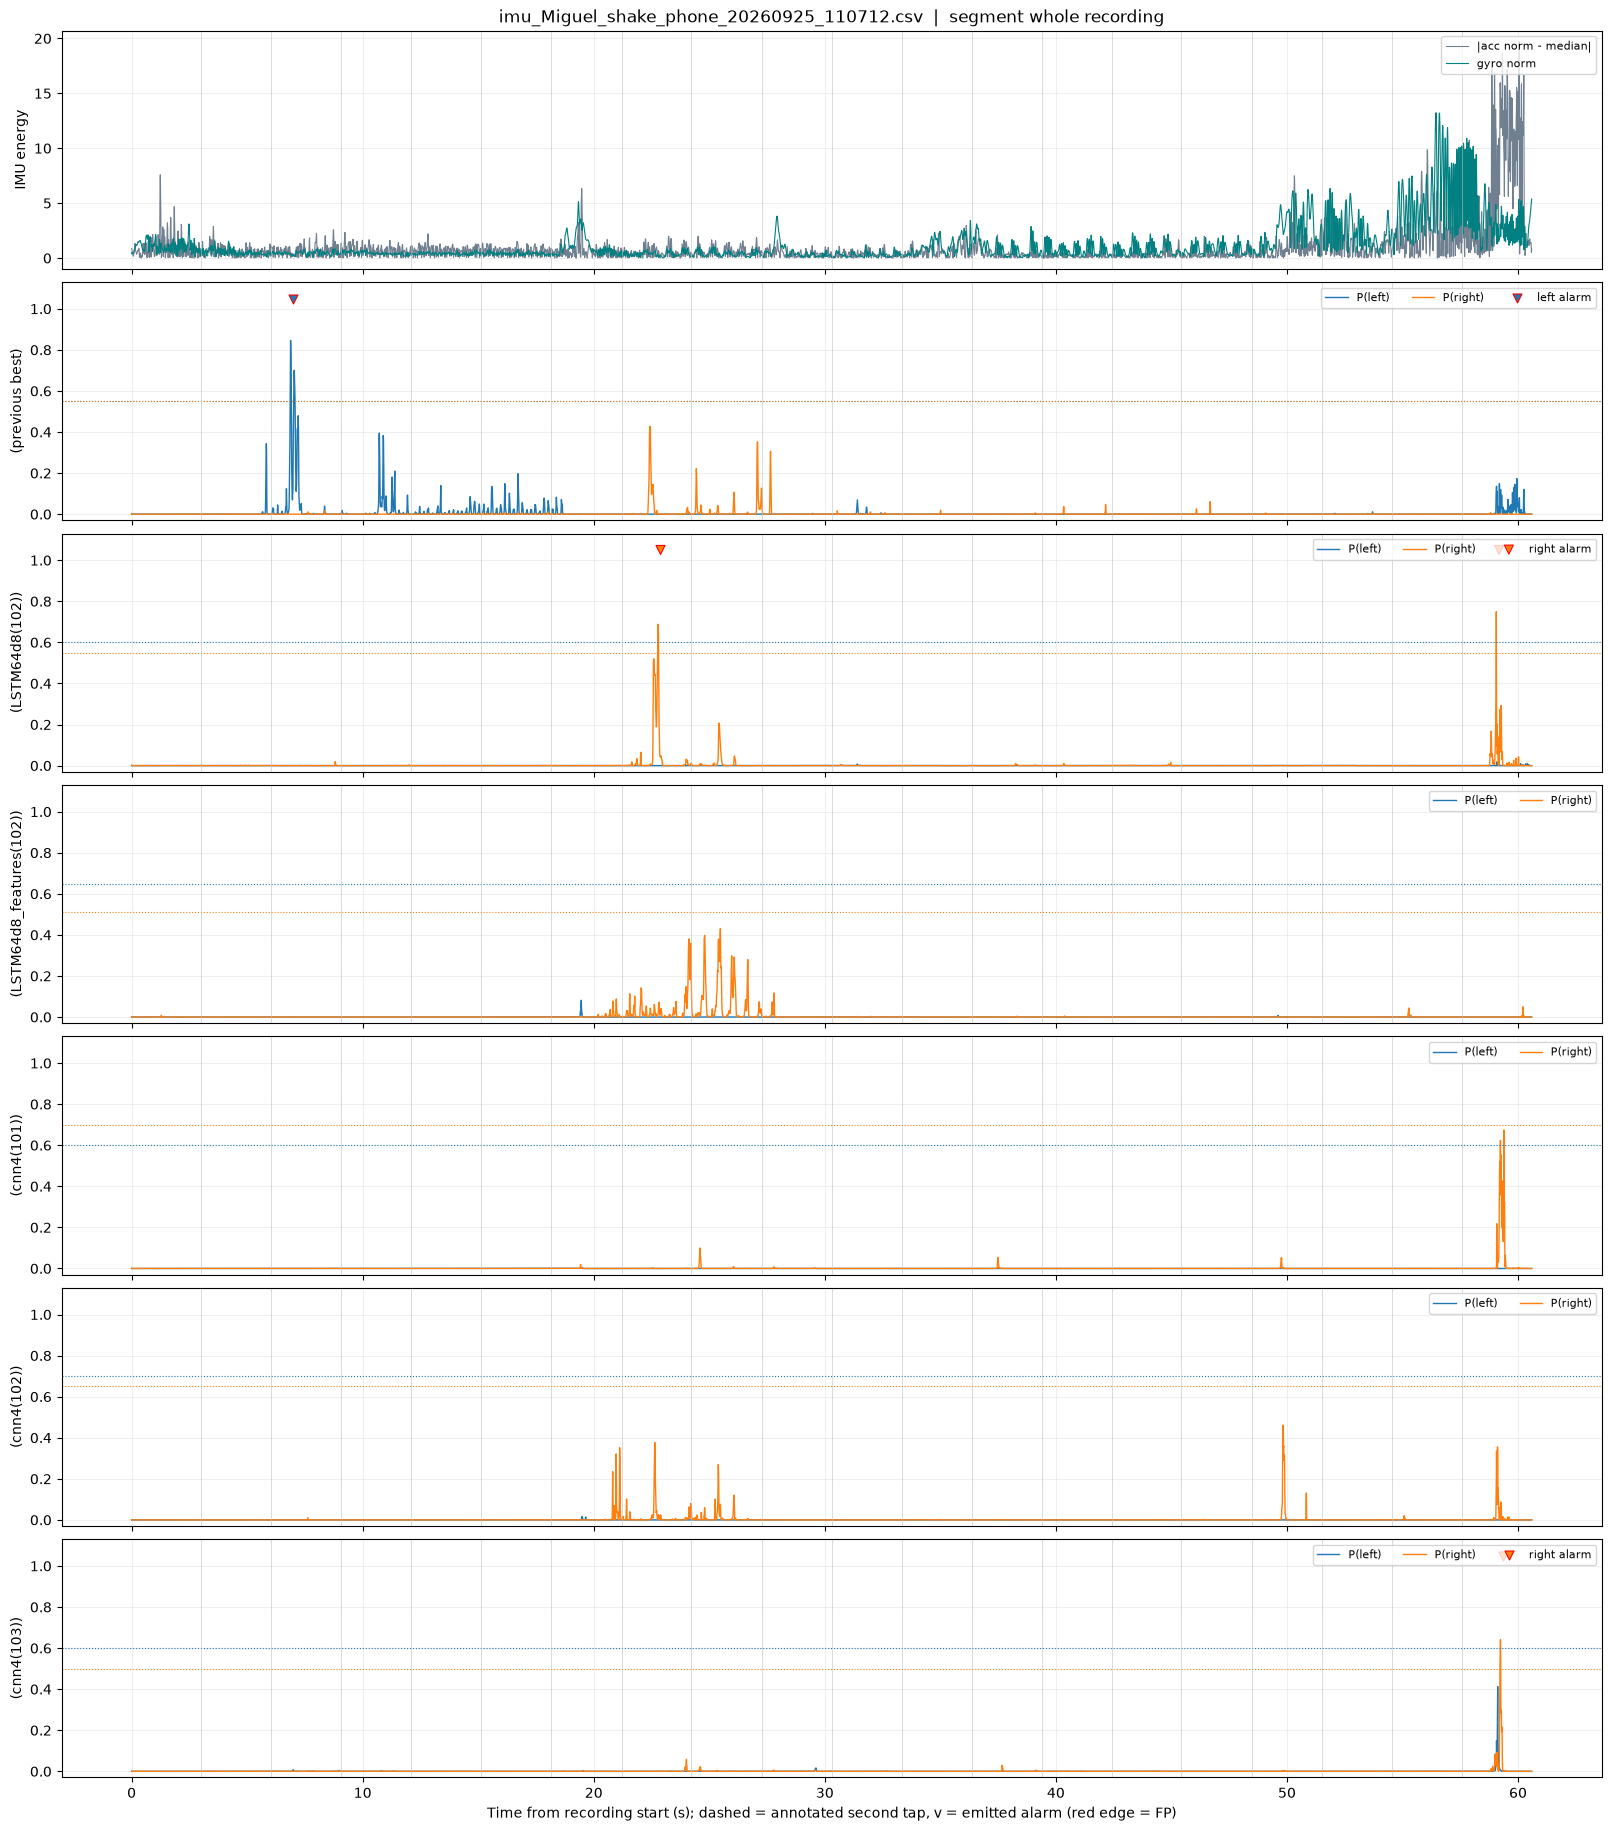

In [114]:
# Replace these values with a file and segment_index from segment_difficulty.
hardest = segment_difficulty.query("recording_type == 'knock_twice'").sort_values(
    ['models_missing', 'too_early_fp', 'models_false_alarm'], ascending=False).iloc[0]
# REVIEW_FILE = hardest['file']
# REVIEW_SEGMENT = int(hardest['segment_index'])  # None = whole recording
REVIEW_FILE = 'imu_Miguel_shake_phone_20260925_110712.csv'
REVIEW_SEGMENT = None
display(segment_scores.query('file == @REVIEW_FILE and segment_index == @REVIEW_SEGMENT')
        [['model', 'file', 'segment_index', 'window_true', 'window_pred',
          'event_tp', 'event_fp', 'event_fn', 'too_early_fp', 'latency_frames']])
fig, axes = plot_example(example_recordings, example_traces, alarm_details,
                         detail_points, REVIEW_FILE, REVIEW_SEGMENT)
plt.show()

## Inspect individual training examples (current recordings)
Replay the same selected checkpoints on their **current training files**, using the validation-selected thresholds and alarm policy from `detail_points`. High-pass filtering, window fitting, exclusions, and physical second-tap annotations are handled as in the validation inspection. Inference uses eval mode with no amplitude augmentation; no weights or thresholds are updated.

The `train_*` tables and traces support label review on examples used for fitting the models. Agreement across models, a probability peak away from the annotation, or an unusual rhythm can identify review candidates. Agreement is a clue rather than ground truth: these models share the training labels and can learn the same annotation error. Inspect the raw signal and neighboring segments before deciding whether a physical second-tap label is wrong.

`train_example_data_status` records the current training-data hash; it is not compared with a validation export hash. The replay uses current exclusions, so excluded sessions are absent. Segment IDs come from the CSV's `segment_index`.

In [115]:
train_example_recordings, train_example_traces, train_segment_scores, train_recording_scores, train_alarm_details, train_example_data_status = (
    replay_examples(ROOT, detail_points, split='train')
)
display(train_example_data_status)
print('Training replay:', len(train_segment_scores), 'model/segment rows,',
      len(train_recording_scores), 'model/recording rows,', len(train_alarm_details), 'alarms')

  Excluding session(s) [8] from imuStrict_Miguel_knock_twice_left_20260929_115133.csv
  Excluding session(s) [15] from imu_Miguel_knock_twice_left_20260924_093125.csv
  Excluding session(s) [2, 6, 12, 13, 16, 19] from imu_Miguel_knock_twice_left_20260925_105524.csv
  Excluding session(s) [1, 6, 7, 10, 17, 19] from imu_Miguel_knock_twice_left_20260925_152309.csv
  Excluding session(s) [10, 19] from imu_Miguel_knock_twice_right_20260923_113114.csv
  Excluding session(s) [2, 9] from imu_Miguel_knock_twice_right_20260924_093233.csv
  Excluding session(s) [4, 9, 13, 14, 16, 18, 19, 20] from imu_Miguel_knock_twice_right_20260925_105401.csv
  Excluding session(s) [19] from imu_Miguel_knock_twice_right_20260925_152103.csv
  Excluding session(s) [1] from imu_OLV_knock_twice_left_20260923_174506.csv


,model,split,current_training_sha256
0,(previous best),train,2d50d6356992ab3c6d197a9f15c463f28a5b18805f18d8...
1,(LSTM64d8(102)),train,2d50d6356992ab3c6d197a9f15c463f28a5b18805f18d8...
2,(LSTM64d8_features(102)),train,2d50d6356992ab3c6d197a9f15c463f28a5b18805f18d8...
3,(cnn4(101)),train,2d50d6356992ab3c6d197a9f15c463f28a5b18805f18d8...
4,(cnn4(102)),train,2d50d6356992ab3c6d197a9f15c463f28a5b18805f18d8...
5,(cnn4(103)),train,2d50d6356992ab3c6d197a9f15c463f28a5b18805f18d8...


Training replay: 13512 model/segment rows, 684 model/recording rows, 8415 alarms


### Find difficult segments and recordings for training examples
`train_segment_scores`, `train_recording_scores`, and `train_alarm_details` have the same inspection fields as the validation tables. `train_segment_matrix` and `train_recording_matrix` align models side by side. `train_segment_difficulty` adds `n_models` and `models_detecting` to the error counts so you can filter for shared disagreements. For example, use `.query('models_missing == n_models or models_false_alarm == n_models')` to find segments where every model has a missed annotation or an unmatched alarm. These counts do not establish that the models selected the same physical moment; inspect the aligned plots for timing agreement.

Use `train_segment_scores.query("recording_type == 'knock_twice' and event_fn > 0")` for missed taps, or `.query('event_fp > 0')` for unmatched alarms in positive or negative recordings. `train_alarm_details` includes original global peak/emission frames and the closest annotation. Window classification is separate from continuous alarm matching.

In [116]:
train_segment_matrix = comparison_matrix(train_segment_scores, ['file', 'segment_index'],
    ['window_true', 'window_pred', 'window_correct', 'window_fp', 'window_fn',
     'p_left_max', 'p_right_max', 'event_tp', 'event_fp', 'event_fn',
     'too_early_fp', 'wrong_side_fp', 'latency_frames'])
train_recording_matrix = comparison_matrix(train_recording_scores, ['file'],
    ['recording_type', 'minutes', 'n_windows', 'window_accuracy', 'window_fp', 'window_fn',
     'n_true_events', 'event_tp', 'event_fp', 'event_fn', 'too_early_fp',
     'wrong_side_fp', 'event_fp_per_min'])
train_segment_difficulty = train_segment_scores.groupby(
    ['file', 'segment_index', 'recording_type'], as_index=False).agg(
        n_models=('model', 'nunique'), n_true_events=('n_true_events', 'first'),
        models_detecting=('n_alarms', lambda x: (x > 0).sum()),
        models_missing=('event_fn', lambda x: (x > 0).sum()),
        models_false_alarm=('event_fp', lambda x: (x > 0).sum()),
        models_window_wrong=('window_correct', lambda x: (x == False).sum()),
        too_early_fp=('too_early_fp', 'sum'), wrong_side_fp=('wrong_side_fp', 'sum'))
with pd.option_context('display.max_colwidth', None):
    print('Hard training double-tap segments (one row per CSV segment):')
    display(train_segment_difficulty.query("recording_type == 'knock_twice'")
            .sort_values(['models_missing', 'too_early_fp', 'models_false_alarm'],
                         ascending=False).head(25))
    print('Training segments with shared annotation disagreements:')
    display(train_segment_difficulty.query(
        'models_missing == n_models or models_false_alarm == n_models')
        .sort_values(['models_missing', 'models_false_alarm'], ascending=False).head(25))
    print('Hard training recordings (one row per model/recording):')
    display(train_recording_scores.sort_values(['event_fp_per_min', 'event_fn'], ascending=False)
            [['model', 'file', 'recording_type', 'n_true_events', 'event_tp', 'event_fp',
              'event_fn', 'too_early_fp', 'window_fp', 'event_fp_per_min']].head(25))

Hard training double-tap segments (one row per CSV segment):


,file,segment_index,recording_type,n_models,n_true_events,models_detecting,models_missing,models_false_alarm,models_window_wrong,too_early_fp,wrong_side_fp
770,imuStrict_Miguel_knock_twice_right_20261002_110007.csv,12,knock_twice,6,1,6,6,6,0,0,0
1210,imu_Miguel_knock_twice_left_20260925_105524.csv,18,knock_twice,6,1,0,6,0,0,0,0
739,imuStrict_Miguel_knock_twice_right_20261002_105132.csv,1,knock_twice,6,1,6,5,6,0,0,0
1344,imu_Miguel_knock_twice_right_20260924_093233.csv,1,knock_twice,6,1,1,5,0,0,0,0
446,imuStrict_Miguel_knock_twice_left_20261006_094941.csv,8,knock_twice,6,1,5,4,3,1,0,0
442,imuStrict_Miguel_knock_twice_left_20261006_094941.csv,4,knock_twice,6,1,2,4,0,4,0,0
754,imuStrict_Miguel_knock_twice_right_20261002_105132.csv,16,knock_twice,6,1,6,3,3,0,0,0
225,imuStrict_Miguel_knock_twice_left_20260930_151654.csv,7,knock_twice,6,1,5,3,2,1,0,0
447,imuStrict_Miguel_knock_twice_left_20261006_094941.csv,9,knock_twice,6,1,5,3,2,1,0,0
158,imuStrict_Miguel_knock_twice_left_20260930_103727.csv,20,knock_twice,6,1,3,3,0,3,0,0


Training segments with shared annotation disagreements:


,file,segment_index,recording_type,n_models,n_true_events,models_detecting,models_missing,models_false_alarm,models_window_wrong,too_early_fp,wrong_side_fp
770,imuStrict_Miguel_knock_twice_right_20261002_110007.csv,12,knock_twice,6,1,6,6,6,0,0,0
1210,imu_Miguel_knock_twice_left_20260925_105524.csv,18,knock_twice,6,1,0,6,0,0,0,0
739,imuStrict_Miguel_knock_twice_right_20261002_105132.csv,1,knock_twice,6,1,6,5,6,0,0,0
1407,imu_Miguel_knock_twice_right_20260925_152103.csv,14,knock_twice,6,1,6,2,6,0,0,0
1312,imu_Miguel_knock_twice_right_20260923_113114.csv,7,knock_twice,6,1,6,1,6,0,0,0
1335,imu_Miguel_knock_twice_right_20260923_173517.csv,12,knock_twice,6,1,6,1,6,0,0,0
1098,imu_Miguel_knock_once_20261005_153635.csv,20,knock_once,6,0,6,0,6,6,0,0
1410,imu_Miguel_knock_twice_right_20260925_152103.csv,17,knock_twice,6,1,6,0,6,0,0,0


Hard training recordings (one row per model/recording):


,model,file,recording_type,n_true_events,event_tp,event_fp,event_fn,too_early_fp,window_fp,event_fp_per_min
671,(previous best),imu_Miguel_switch_hand_20261005_175627.csv,switch_hand,0,0,15,0,0,11,14.853936
669,(previous best),imu_Miguel_switch_hand_20261005_175105.csv,switch_hand,0,0,13,0,0,10,12.877662
666,(previous best),imu_Miguel_switch_hand_20261005_151845.csv,switch_hand,0,0,11,0,0,9,10.900083
670,(previous best),imu_Miguel_switch_hand_20261005_175415.csv,switch_hand,0,0,11,0,0,10,10.894685
672,(previous best),imu_Miguel_switch_hand_20261005_175913.csv,switch_hand,0,0,9,0,0,8,8.912362
557,(cnn4(103)),imu_Miguel_switch_hand_20261005_175627.csv,switch_hand,0,0,8,0,0,8,7.922099
668,(previous best),imu_Miguel_switch_hand_20261005_154207.csv,switch_hand,0,0,6,0,0,6,5.940594
54,(LSTM64d8(102)),imu_Miguel_knock_once_20261005_153635.csv,knock_once,0,0,5,0,0,2,4.957039
510,(cnn4(103)),imu_Miguel_knock_once_20261005_153635.csv,knock_once,0,0,5,0,0,4,4.957039
673,(previous best),imu_Miguel_switch_hand_20261006_094345.csv,switch_hand,0,0,5,0,0,5,4.952947


### Aligned recording/segment inspection on training examples
Choose `TRAIN_REVIEW_FILE` and `TRAIN_REVIEW_SEGMENT` from `train_segment_difficulty`. The default selects a difficult training double-tap segment; set `TRAIN_REVIEW_SEGMENT = None` to inspect the entire recording and compare the rhythm with neighboring sessions. The raw IMU row, annotated physical second taps, model probabilities, thresholds, and emitted alarms share the original recording's time axis. Training-target delay is not added to the annotation markers.

For tabular inspection of all models together, use `train_segment_matrix.loc[('filename.csv', 8)]` or `train_recording_matrix.loc['filename.csv']`. To check an individual alarm, filter `train_alarm_details` by file and segment.

,model,file,segment_index,window_true,window_pred,event_tp,event_fp,event_fn,too_early_fp,latency_frames
1933,(previous best),imu_Miguel_switch_hand_20261005_154207.csv,1,0,0,0,0,0,0,NaN
1934,(previous best),imu_Miguel_switch_hand_20261005_154207.csv,2,0,0,0,0,0,0,NaN
1935,(previous best),imu_Miguel_switch_hand_20261005_154207.csv,3,0,0,0,0,0,0,NaN
1936,(previous best),imu_Miguel_switch_hand_20261005_154207.csv,4,0,0,0,0,0,0,NaN
1937,(previous best),imu_Miguel_switch_hand_20261005_154207.csv,5,0,2,0,1,0,0,NaN
...,...,...,...,...,...,...,...,...,...,...
13208,(cnn4(103)),imu_Miguel_switch_hand_20261005_154207.csv,16,0,0,0,0,0,0,NaN
13209,(cnn4(103)),imu_Miguel_switch_hand_20261005_154207.csv,17,0,0,0,0,0,0,NaN
13210,(cnn4(103)),imu_Miguel_switch_hand_20261005_154207.csv,18,0,0,0,0,0,0,NaN
13211,(cnn4(103)),imu_Miguel_switch_hand_20261005_154207.csv,19,0,0,0,0,0,0,NaN


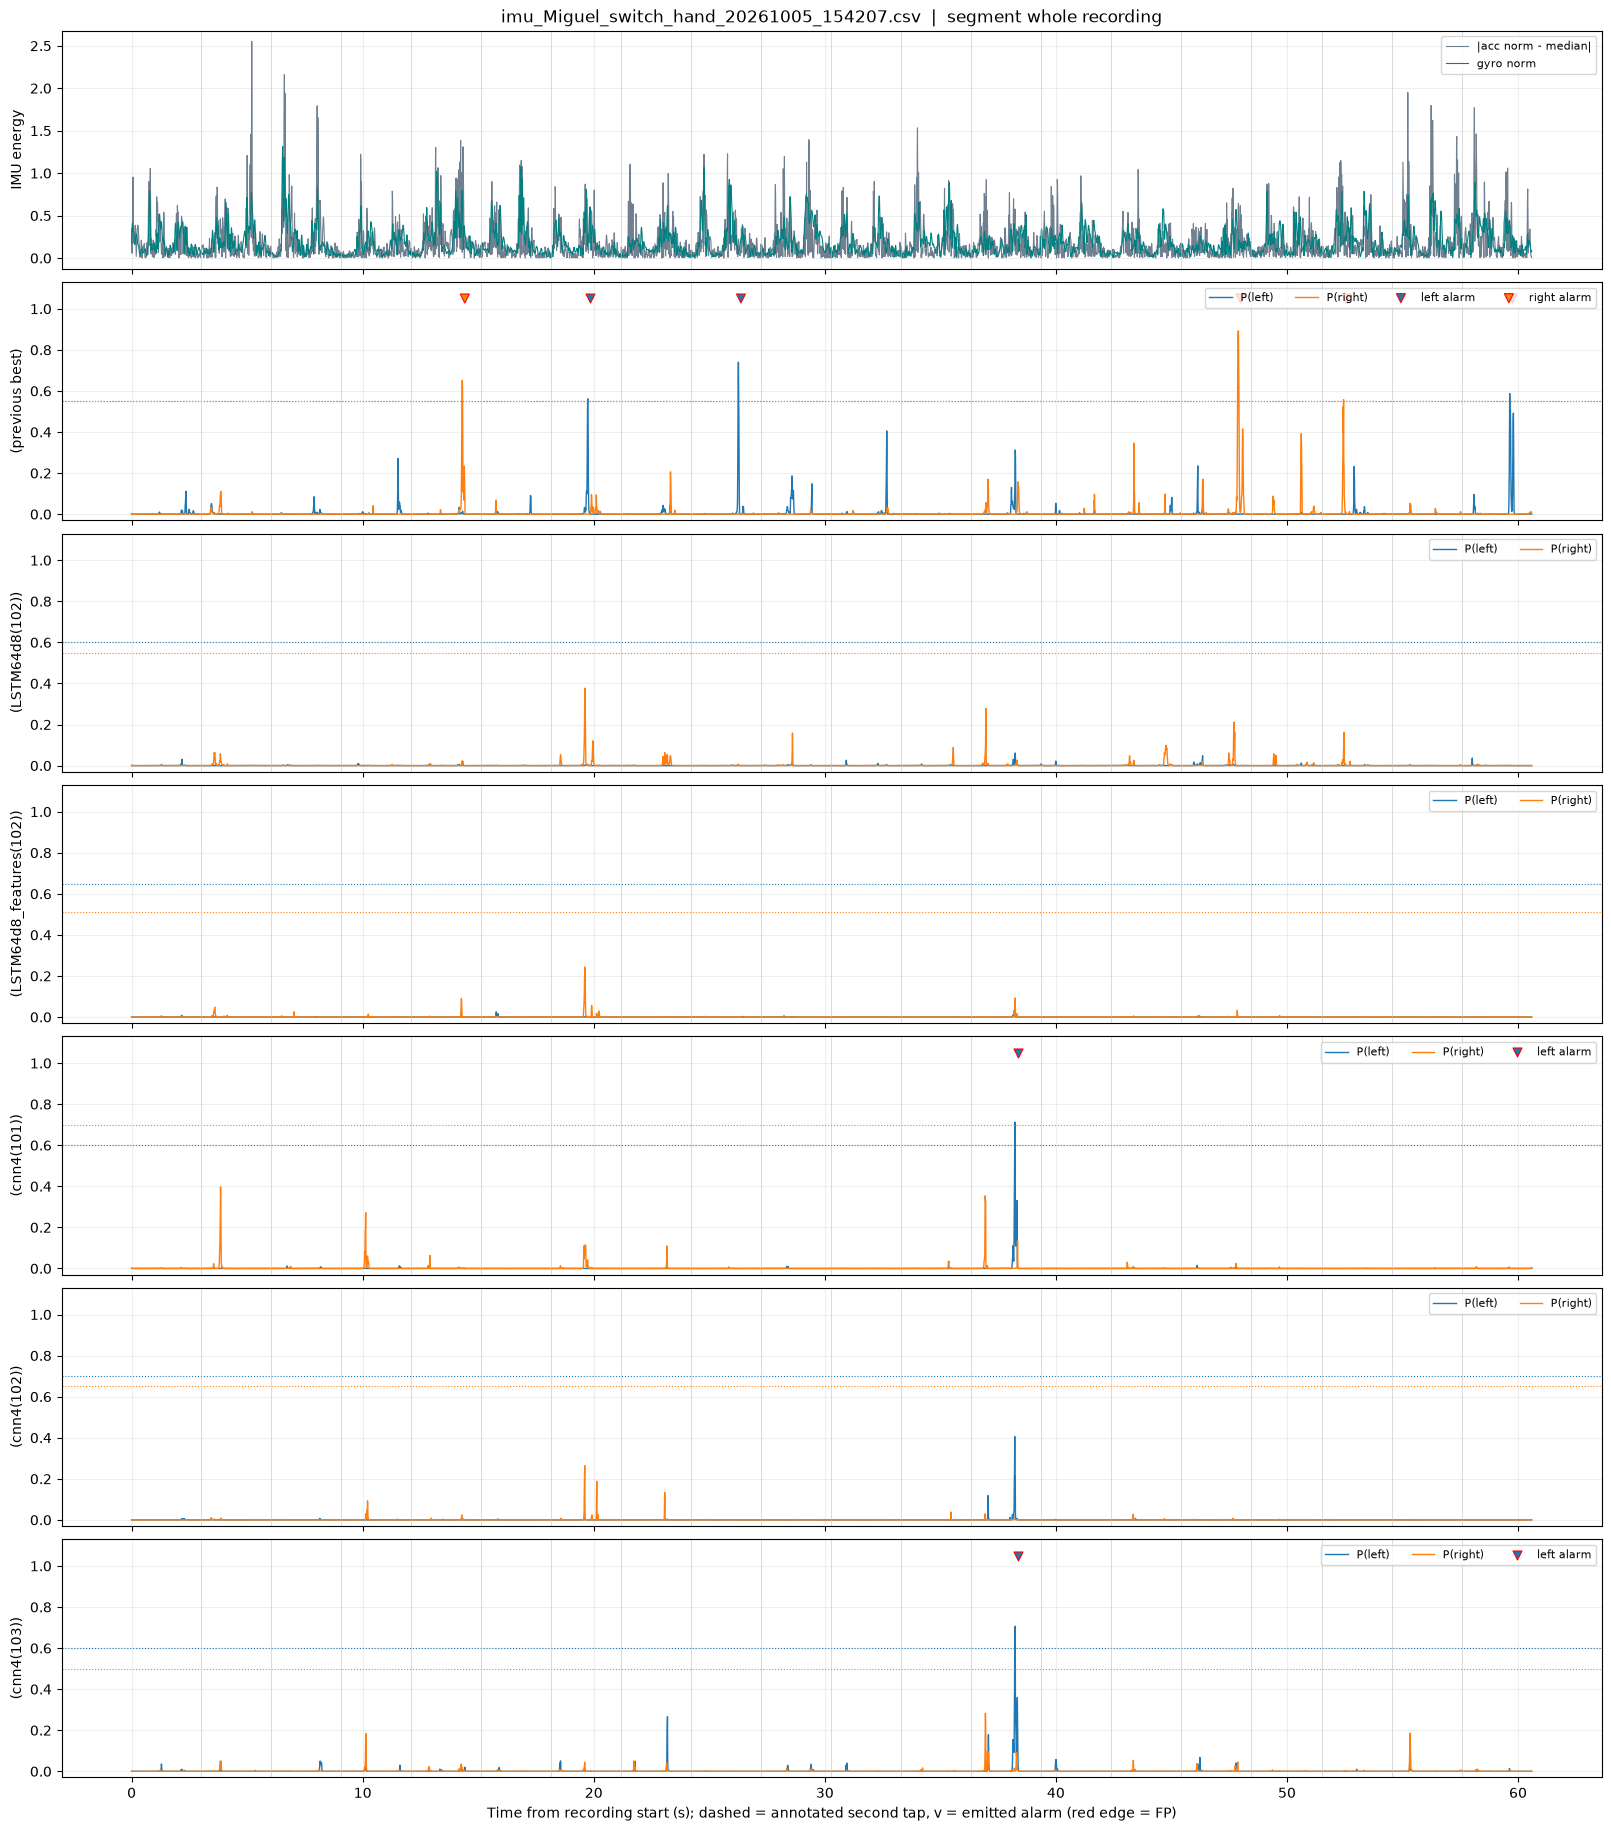

In [117]:
train_review_candidates = train_segment_difficulty.query("recording_type == 'knock_twice'")
if train_review_candidates.empty:
    train_review_candidates = train_segment_difficulty
train_hardest = train_review_candidates.sort_values(
    ['models_missing', 'too_early_fp', 'models_false_alarm'], ascending=False).iloc[0]
# Replace these values with a file and CSV segment_index from the training tables.
TRAIN_REVIEW_FILE = 'imu_Miguel_switch_hand_20261005_154207.csv'
TRAIN_REVIEW_SEGMENT = None  # None = whole recording
train_review_rows = train_segment_scores[train_segment_scores.file == TRAIN_REVIEW_FILE]
if TRAIN_REVIEW_SEGMENT is not None:
    train_review_rows = train_review_rows[train_review_rows.segment_index == TRAIN_REVIEW_SEGMENT]
display(train_review_rows[['model', 'file', 'segment_index', 'window_true', 'window_pred',
                         'event_tp', 'event_fp', 'event_fn', 'too_early_fp', 'latency_frames']])
train_fig, train_axes = plot_example(train_example_recordings, train_example_traces, train_alarm_details,
                                    detail_points, TRAIN_REVIEW_FILE, TRAIN_REVIEW_SEGMENT)
plt.show()